In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 1000)
from pyspark.sql.functions import sum as _sum
from pyspark.sql.functions import when, col, countDistinct, datediff, collect_set
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import IntegerType, FloatType, StringType, DateType

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Split") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")
spark.conf.set("spark.sql.shuffle.partitions", "400")
csv_file_path = "data/OASIS_v2_sampled.csv"
df = spark.read.csv(csv_file_path, header=True, inferSchema=True)
df.columns

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/25 09:14:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/25 09:14:09 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/11/25 09:14:09 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
                                                                                

['Beneficiary_ID',
 'Assessment_ID',
 'Assessment_Effective_Date',
 'Calculated_HIPPS_Code',
 'Facility_Internal_ID',
 'HHA_Assessment_Internal_ID',
 'State_ID',
 'Submission_Date',
 'Submitted_HIPPS_Code',
 'Agency_Medicare_Number',
 'Branch_State',
 'Branch_Identifier_Number',
 'Start_of_Care_Date',
 'Resumption_of_Care_Date_NA',
 'Resumption_of_Care_Date',
 'Patient_State',
 'Patient_ZIP_Code',
 'Patient_Birth_Date',
 'Gender',
 'American_Indian_or_Alaska_Native',
 'Asian',
 'Black_or_African_American',
 'Hispanic_or_Latino',
 'Native_Hawiian_or_Pacific_Islander',
 'Unknown_Race_Ethnicity',
 'White',
 'Medicare_Fee_For_Service',
 'Medicare_HMO_Managed_Care',
 'Date_of_Last_Home_Visit',
 'Discharge_Transfer_Death_Date',
 'Medicare_HHA_pymnt_episode_asmt_case_mix_grp_early_later_episode',
 'Discharged_Past_14_Days_From_IPPS',
 'Discharged_Past_14_Days_From_IRF',
 'Discharged_Past_14_Days_From_LTC',
 'Discharged_Past_14_Days_From_LTCH',
 'Discharged_Past_14_Days_From_Other',
 'Discharg

1. Missing values per column
2. Missing values per Beneficiary_ID (total)
3. Missingness heatmap (rows = patients, columns = features)

25/11/25 09:14:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

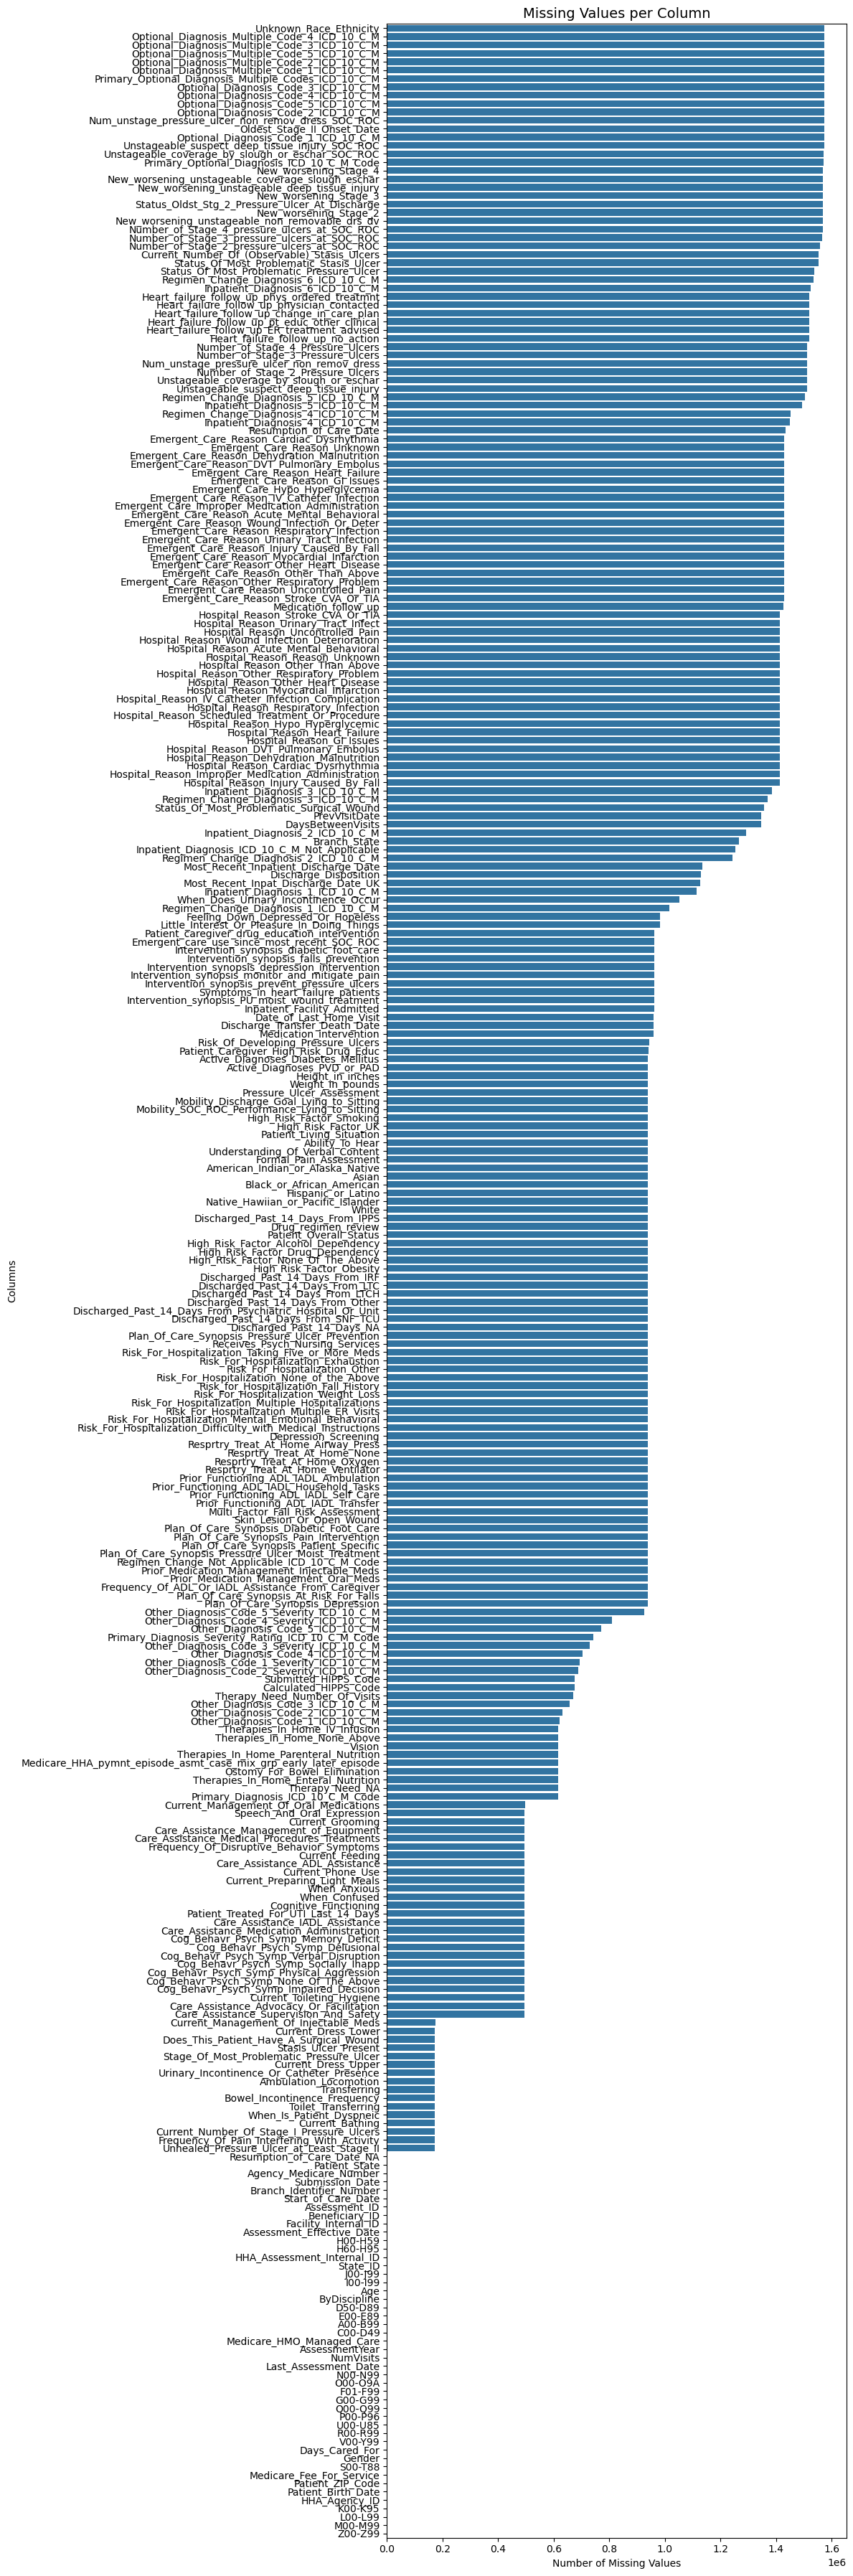

In [3]:
missing_per_col = df.select([
    F.count(F.when(F.col(c).isNull() | (F.col(c) == ''), c)).alias(c)
    for c in df.columns
])
missing_per_col_pd = missing_per_col.toPandas().T.reset_index()
missing_per_col_pd.columns = ['Column', 'MissingCount']

# Plot: Missing per column
plt.figure(figsize=(12, 36))
sns.barplot(data=missing_per_col_pd.sort_values('MissingCount', ascending=False),
            x='MissingCount', y='Column')
plt.title("Missing Values per Column", fontsize=14)
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")
plt.tight_layout()
plt.show()

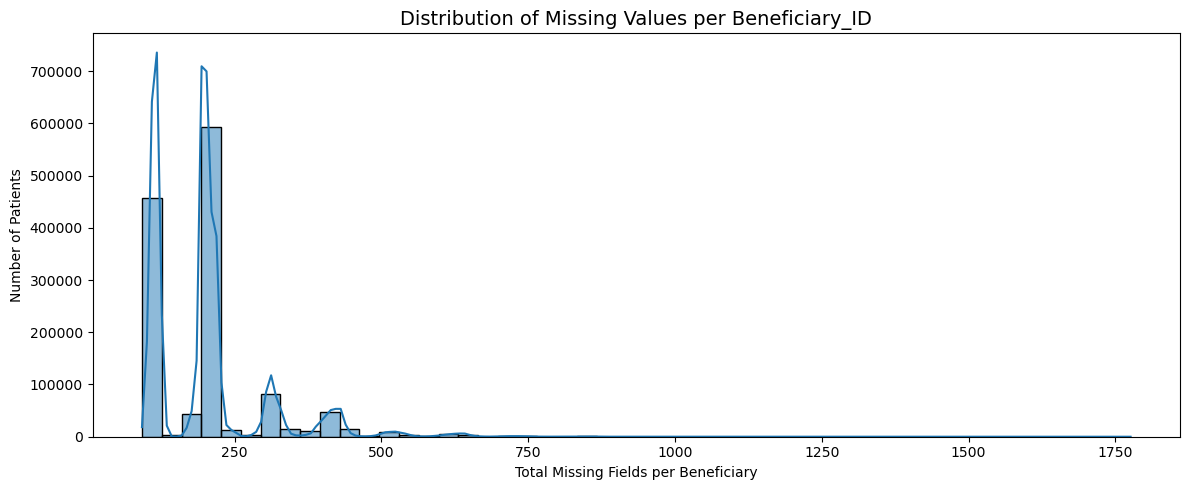

In [4]:
cols_to_check = [c for c in df.columns if c != 'Beneficiary_ID']

missing_per_patient = df.groupBy('Beneficiary_ID').agg(
    *[
        F.sum(F.when(F.col(c).isNull() | (F.col(c) == ''), 1).otherwise(0)).alias(f"{c}_missing")
        for c in cols_to_check
    ]
)
# total missing per patient
missing_summary = missing_per_patient.withColumn(
    "total_missing",
    sum(F.col(c) for c in missing_per_patient.columns if c != "Beneficiary_ID")
)

missing_summary_pd = missing_summary.select("Beneficiary_ID", "total_missing").toPandas()

# Plot: Missing per Beneficiary_ID
plt.figure(figsize=(12, 5))
sns.histplot(missing_summary_pd["total_missing"], bins=50, kde=True)
plt.title("Distribution of Missing Values per Beneficiary_ID", fontsize=14)
plt.xlabel("Total Missing Fields per Beneficiary")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


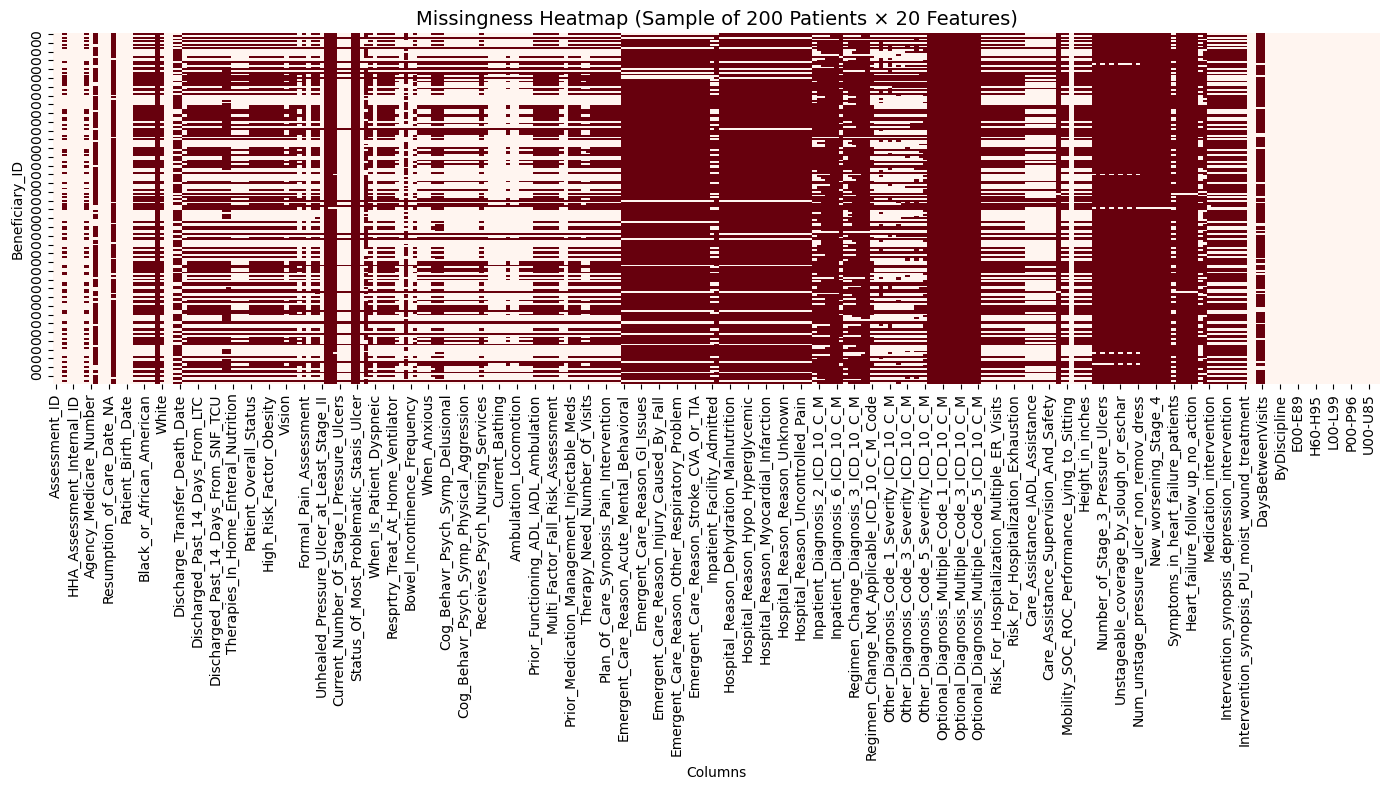

In [5]:
sample_df = df.select(['Beneficiary_ID'] + cols_to_check).limit(200).toPandas()
missing_matrix = sample_df.isnull().astype(int)

plt.figure(figsize=(14, 8))
sns.heatmap(missing_matrix.set_index('Beneficiary_ID'), cmap="Reds", cbar=False)
plt.title("Missingness Heatmap (Sample of 200 Patients × 20 Features)", fontsize=14)
plt.xlabel("Columns")
plt.ylabel("Beneficiary_ID")
plt.tight_layout()
plt.show()

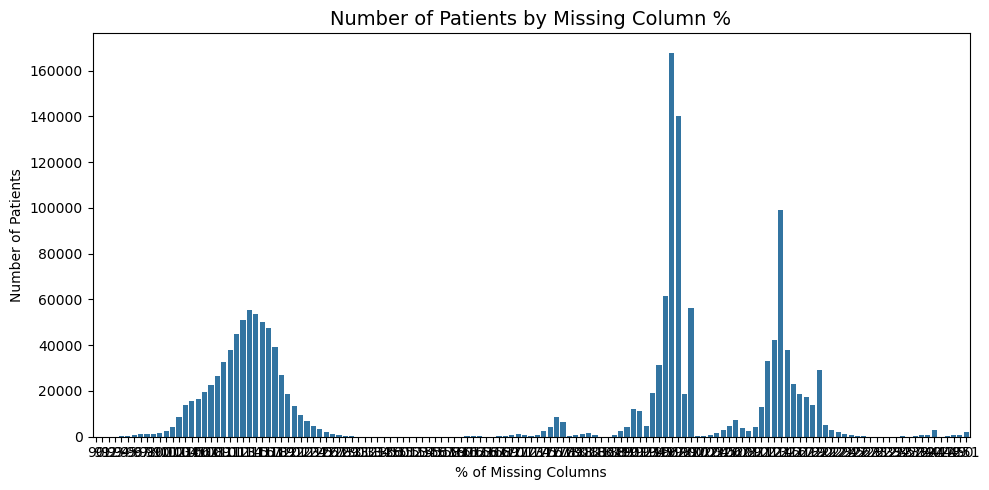

In [6]:
missing_per_patient = df.withColumn(
    "num_missing",
    sum(
        F.when(F.col(c).isNull() | (F.col(c) == ''), 1).otherwise(0)
        for c in cols_to_check
    )
).select("Beneficiary_ID", "num_missing")
missing_distribution = missing_per_patient.groupBy("num_missing").count().orderBy("num_missing")


missing_distribution_pd = missing_distribution.toPandas()

plt.figure(figsize=(10,5))
sns.barplot(data=missing_distribution_pd, x="num_missing", y="count")
plt.title("Number of Patients by Missing Column %", fontsize=14)
plt.xlabel("% of Missing Columns")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

In [7]:
total_rows = df.count()
missing_summary = []
for c in df.columns:
    missing_count = df.filter(F.col(c).isNull() | (F.col(c) == '')).count()
    missing_pct = (missing_count / total_rows) * 100
    missing_summary.append((c, missing_count, missing_pct))

# Convert to DataFrame
missing_df = spark.createDataFrame(missing_summary, ["column", "missing_count", "missing_percent"])

missing_df = missing_df.withColumn(
    "missing_group",
    (F.round(F.col("missing_percent") / 10) * 10).cast("int")
)

# Aggregate columns by group
grouped = (
    missing_df.groupBy("missing_group")
    .agg(F.collect_list("column").alias("columns"),
         F.count("column").alias("num_columns"))
    .orderBy("missing_group")
)
grouped_pd = grouped.toPandas()

for idx, row in grouped_pd.iterrows():
    print(f"\n=== Columns ~{row['missing_group']}% Missing ({row['num_columns']} total) ===")
    for col in row['columns']:
        print(f"  • {col}")

[Stage 920:>                                                      (0 + 96) / 96]


=== Columns ~0% Missing (46 total) ===
  • Beneficiary_ID
  • Assessment_ID
  • Assessment_Effective_Date
  • Facility_Internal_ID
  • HHA_Assessment_Internal_ID
  • State_ID
  • Submission_Date
  • Agency_Medicare_Number
  • Branch_Identifier_Number
  • Start_of_Care_Date
  • Resumption_of_Care_Date_NA
  • Patient_State
  • Patient_ZIP_Code
  • Patient_Birth_Date
  • Gender
  • Medicare_Fee_For_Service
  • Medicare_HMO_Managed_Care
  • HHA_Agency_ID
  • AssessmentYear
  • NumVisits
  • Last_Assessment_Date
  • Days_Cared_For
  • Age
  • ByDiscipline
  • A00-B99
  • C00-D49
  • D50-D89
  • E00-E89
  • F01-F99
  • G00-G99
  • H00-H59
  • H60-H95
  • I00-I99
  • J00-J99
  • K00-K95
  • L00-L99
  • M00-M99
  • N00-N99
  • O00-O9A
  • P00-P96
  • Q00-Q99
  • R00-R99
  • S00-T88
  • U00-U85
  • V00-Y99
  • Z00-Z99

=== Columns ~10% Missing (16 total) ===
  • Frequency_Of_Pain_Interfering_With_Activity
  • Unhealed_Pressure_Ulcer_at_Least_Stage_II
  • Current_Number_Of_Stage_I_Pressure_Ulce

In [8]:
missing_df.orderBy(F.desc("missing_percent")).toPandas().to_csv("data/missingness_summary.csv", index=False)

In [9]:
df_missing_age = df.filter(F.col("Age").isNull())

# Total rows with missing Age
total_missing_age = df_missing_age.count()

missing_summary_age = []
for c in df.columns:
    missing_count = df_missing_age.filter(F.col(c).isNull() | (F.col(c) == '')).count()
    missing_pct = (missing_count / total_missing_age) * 100 if total_missing_age > 0 else 0
    missing_summary_age.append((c, missing_count, missing_pct))

# Convert to DataFrame
missing_df_age = spark.createDataFrame(missing_summary_age, ["column", "missing_count", "missing_percent"])

missing_df_age = missing_df_age.withColumn(
    "missing_group",
    (F.round(F.col("missing_percent") / 10) * 10).cast("int")
)

grouped_age = (
    missing_df_age.groupBy("missing_group")
    .agg(F.collect_list("column").alias("columns"),
         F.count("column").alias("num_columns"))
    .orderBy("missing_group")
)

# Convert to Pandas to print nicely
grouped_pd_age = grouped_age.toPandas()

for idx, row in grouped_pd_age.iterrows():
    print(f"\n=== Columns ~{row['missing_group']}% Missing among rows with missing Age ({row['num_columns']} total) ===")
    for col in row['columns']:
        print(f"  • {col}")


=== Columns ~0% Missing among rows with missing Age (300 total) ===
  • Beneficiary_ID
  • Assessment_ID
  • Assessment_Effective_Date
  • Calculated_HIPPS_Code
  • Facility_Internal_ID
  • HHA_Assessment_Internal_ID
  • State_ID
  • Submission_Date
  • Submitted_HIPPS_Code
  • Agency_Medicare_Number
  • Branch_State
  • Branch_Identifier_Number
  • Start_of_Care_Date
  • Resumption_of_Care_Date_NA
  • Resumption_of_Care_Date
  • Patient_State
  • Patient_ZIP_Code
  • Patient_Birth_Date
  • Gender
  • American_Indian_or_Alaska_Native
  • Asian
  • Black_or_African_American
  • Hispanic_or_Latino
  • Native_Hawiian_or_Pacific_Islander
  • Unknown_Race_Ethnicity
  • White
  • Medicare_Fee_For_Service
  • Medicare_HMO_Managed_Care
  • Date_of_Last_Home_Visit
  • Discharge_Transfer_Death_Date
  • Medicare_HHA_pymnt_episode_asmt_case_mix_grp_early_later_episode
  • Discharged_Past_14_Days_From_IPPS
  • Discharged_Past_14_Days_From_IRF
  • Discharged_Past_14_Days_From_LTC
  • Discharged_Pas